# DhakaNest Final Model Comparison and Production Export

This notebook compares the completed Random Forest, XGBoost, and CatBoost
candidates using validation results.

The winning algorithm is selected before the official test dataset is opened.
Only the selected algorithm is evaluated on the untouched test set.

After official testing, the winning XGBoost configuration is retrained using
the combined training and validation datasets and exported as the final
production bundle.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import subprocess
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/DhakaNest_ML"
)

XGB_ENVIRONMENT_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "candidates"
    / "xgboost"
    / "training_environment.json"
)

if not XGB_ENVIRONMENT_PATH.exists():
    raise FileNotFoundError(
        f"Missing environment file: {XGB_ENVIRONMENT_PATH}"
    )

with XGB_ENVIRONMENT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    saved_xgb_environment = json.load(file)

print(
    json.dumps(
        saved_xgb_environment,
        indent=2,
    )
)

{
  "python_version": "3.12.13",
  "pandas_version": "2.2.2",
  "numpy_version": "2.0.2",
  "scikit_learn_version": "1.6.1",
  "xgboost_version": "3.3.0",
  "joblib_version": "1.5.3",
  "random_state": 42,
  "created_at_utc": "2026-07-31T05:09:30.545618+00:00"
}


In [3]:
xgboost_version = saved_xgb_environment[
    "xgboost_version"
]

sklearn_version = saved_xgb_environment[
    "scikit_learn_version"
]

joblib_version = saved_xgb_environment[
    "joblib_version"
]

packages_to_install = [
    f"xgboost=={xgboost_version}",
    f"scikit-learn=={sklearn_version}",
    f"joblib=={joblib_version}",
]

print("Installing:")
for package in packages_to_install:
    print("-", package)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    *packages_to_install,
])

print("Matching model-loading packages installed.")

Installing:
- xgboost==3.3.0
- scikit-learn==1.6.1
- joblib==1.5.3
Matching model-loading packages installed.


In [4]:
from datetime import datetime, timezone
from time import perf_counter

import hashlib
import importlib.util
import os
import platform
import random
import shutil
import textwrap
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("Joblib:", joblib.__version__)

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
SciPy: 1.16.3
Scikit-learn: 1.6.1
XGBoost: 3.3.0
Joblib: 1.5.3


In [5]:
assert xgb.__version__ == xgboost_version, (
    "XGBoost version does not match the candidate environment."
)

assert sklearn.__version__ == sklearn_version, (
    "Scikit-learn version does not match the candidate environment."
)

assert joblib.__version__ == joblib_version, (
    "Joblib version does not match the candidate environment."
)

print("Candidate environment version check passed.")

Candidate environment version check passed.


In [6]:
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(
    RANDOM_STATE
)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)

Random state: 42


In [7]:
DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"

REPORTS_DIR = PROJECT_ROOT / "reports"
METRICS_DIR = REPORTS_DIR / "metrics"
SEGMENT_DIR = REPORTS_DIR / "segment_evaluation"

COMPARISON_FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
    / "comparison"
)

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

RF_ARTIFACT_DIR = (
    ARTIFACTS_DIR
    / "candidates"
    / "random_forest"
)

XGB_ARTIFACT_DIR = (
    ARTIFACTS_DIR
    / "candidates"
    / "xgboost"
)

CAT_ARTIFACT_DIR = (
    ARTIFACTS_DIR
    / "candidates"
    / "catboost"
)

WINNING_BUNDLE_DIR = (
    ARTIFACTS_DIR
    / "winning_model_bundle"
)

PRIMARY_MODEL_DIR = (
    WINNING_BUNDLE_DIR
    / "primary_model"
)

FALLBACK_MODEL_DIR = (
    WINNING_BUNDLE_DIR
    / "fallback_models"
)

BUNDLE_METADATA_DIR = (
    WINNING_BUNDLE_DIR
    / "metadata"
)

MANIFESTS_DIR = PROJECT_ROOT / "manifests"
EXPORTS_DIR = PROJECT_ROOT / "exports"
LOGS_DIR = PROJECT_ROOT / "logs"

TRAIN_PATH = SPLITS_DIR / "train.csv"

VALIDATION_PATH = (
    SPLITS_DIR / "validation.csv"
)

TEST_PATH = SPLITS_DIR / "test.csv"

for directory in [
    METRICS_DIR,
    SEGMENT_DIR,
    COMPARISON_FIGURES_DIR,
    WINNING_BUNDLE_DIR,
    PRIMARY_MODEL_DIR,
    FALLBACK_MODEL_DIR,
    BUNDLE_METADATA_DIR,
    MANIFESTS_DIR,
    EXPORTS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Winning bundle:", WINNING_BUNDLE_DIR)

Winning bundle: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle


In [8]:
RF_METRICS_PATH = (
    RF_ARTIFACT_DIR / "metrics.json"
)

XGB_METRICS_PATH = (
    XGB_ARTIFACT_DIR / "metrics.json"
)

CAT_METRICS_PATH = (
    CAT_ARTIFACT_DIR / "metrics.json"
)

RF_MANIFEST_PATH = (
    RF_ARTIFACT_DIR
    / "model_manifest.json"
)

XGB_MANIFEST_PATH = (
    XGB_ARTIFACT_DIR
    / "model_manifest.json"
)

CAT_MANIFEST_PATH = (
    CAT_ARTIFACT_DIR
    / "model_manifest.json"
)

XGB_CANDIDATE_MODEL_PATH = (
    XGB_ARTIFACT_DIR
    / "xgboost_model.json"
)

XGB_CANDIDATE_PREPROCESSOR_PATH = (
    XGB_ARTIFACT_DIR
    / "preprocessor.joblib"
)

XGB_BEST_PARAMETERS_PATH = (
    XGB_ARTIFACT_DIR
    / "best_parameters.json"
)

XGB_FEATURE_SCHEMA_PATH = (
    XGB_ARTIFACT_DIR
    / "feature_schema.json"
)

In [9]:
required_input_files = [
    TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH,

    RF_METRICS_PATH,
    XGB_METRICS_PATH,
    CAT_METRICS_PATH,

    RF_MANIFEST_PATH,
    XGB_MANIFEST_PATH,
    CAT_MANIFEST_PATH,

    XGB_CANDIDATE_MODEL_PATH,
    XGB_CANDIDATE_PREPROCESSOR_PATH,
    XGB_BEST_PARAMETERS_PATH,
    XGB_FEATURE_SCHEMA_PATH,
]

missing_inputs = [
    str(path)
    for path in required_input_files
    if not path.exists()
]

empty_inputs = [
    str(path)
    for path in required_input_files
    if (
        path.exists()
        and path.is_file()
        and path.stat().st_size == 0
    )
]

if missing_inputs:
    raise FileNotFoundError(
        "Missing required inputs:\n"
        + "\n".join(missing_inputs)
    )

if empty_inputs:
    raise ValueError(
        "Empty required inputs:\n"
        + "\n".join(empty_inputs)
    )

print("All final-comparison inputs exist.")
print("The official test file has not been loaded.")

All final-comparison inputs exist.
The official test file has not been loaded.


In [10]:
def load_json(file_path):
    with Path(file_path).open(
        "r",
        encoding="utf-8",
    ) as file:
        return json.load(file)


def save_json(data, file_path):
    with Path(file_path).open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            data,
            file,
            indent=2,
        )


def calculate_sha256(file_path):
    sha256 = hashlib.sha256()

    with Path(file_path).open("rb") as file:
        for block in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [11]:
rf_manifest = load_json(
    RF_MANIFEST_PATH
)

xgb_manifest = load_json(
    XGB_MANIFEST_PATH
)

cat_manifest = load_json(
    CAT_MANIFEST_PATH
)

candidate_manifests = {
    "Random Forest": rf_manifest,
    "XGBoost": xgb_manifest,
    "CatBoost": cat_manifest,
}

for model_name, manifest in (
    candidate_manifests.items()
):
    assert manifest[
        "artifact_reload_verified"
    ] is True, (
        f"{model_name} reload verification "
        "was not recorded as successful."
    )

    assert manifest[
        "test_rows_used"
    ] == 0, (
        f"{model_name} used official test rows."
    )

print("All three candidate manifests passed.")

All three candidate manifests passed.


In [12]:
expected_xgb_model_checksum = (
    xgb_manifest["checksums"][
        "native_model_sha256"
    ]
)

expected_xgb_preprocessor_checksum = (
    xgb_manifest["checksums"][
        "preprocessor_sha256"
    ]
)

actual_xgb_model_checksum = (
    calculate_sha256(
        XGB_CANDIDATE_MODEL_PATH
    )
)

actual_xgb_preprocessor_checksum = (
    calculate_sha256(
        XGB_CANDIDATE_PREPROCESSOR_PATH
    )
)

assert (
    actual_xgb_model_checksum
    == expected_xgb_model_checksum
), "XGBoost candidate model checksum changed."

assert (
    actual_xgb_preprocessor_checksum
    == expected_xgb_preprocessor_checksum
), "XGBoost preprocessor checksum changed."

print("XGBoost candidate checksums passed.")

XGBoost candidate checksums passed.


In [13]:
rf_metrics = load_json(
    RF_METRICS_PATH
)

xgb_metrics = load_json(
    XGB_METRICS_PATH
)

cat_metrics = load_json(
    CAT_METRICS_PATH
)

candidate_metric_files = {
    "Random Forest": rf_metrics,
    "XGBoost": xgb_metrics,
    "CatBoost": cat_metrics,
}

In [14]:
comparison_rows = []

for model_name, metrics_data in (
    candidate_metric_files.items()
):
    validation_metrics = (
        metrics_data[
            "chosen_candidate"
        ]["validation"]
    )

    train_metrics = (
        metrics_data[
            "chosen_candidate"
        ]["train"]
    )

    comparison_rows.append({
        "model": model_name,
        "target_strategy": (
            metrics_data[
                "target_strategy"
            ]
        ),
        "validation_mae_bdt": (
            validation_metrics[
                "mae_bdt"
            ]
        ),
        "validation_rmse_bdt": (
            validation_metrics[
                "rmse_bdt"
            ]
        ),
        "validation_r2": (
            validation_metrics["r2"]
        ),
        "validation_mape_percent": (
            validation_metrics[
                "mape_percent"
            ]
        ),
        "validation_median_ae_bdt": (
            validation_metrics[
                "median_absolute_error_bdt"
            ]
        ),
        "validation_p90_ae_bdt": (
            validation_metrics[
                "p90_absolute_error_bdt"
            ]
        ),
        "train_mae_bdt": (
            train_metrics["mae_bdt"]
        ),
        "train_validation_mae_gap_bdt": (
            validation_metrics[
                "mae_bdt"
            ]
            - train_metrics[
                "mae_bdt"
            ]
        ),
    })

validation_comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        [
            "validation_mae_bdt",
            "validation_rmse_bdt",
        ],
        ascending=True,
    )
    .reset_index(drop=True)
)

VALIDATION_COMPARISON_PATH = (
    METRICS_DIR
    / "final_model_validation_comparison.csv"
)

validation_comparison_df.to_csv(
    VALIDATION_COMPARISON_PATH,
    index=False,
)

display(validation_comparison_df)

print("Saved:", VALIDATION_COMPARISON_PATH)

,model,target_strategy,validation_mae_bdt,validation_rmse_bdt,validation_r2,validation_mape_percent,validation_median_ae_bdt,validation_p90_ae_bdt,train_mae_bdt,train_validation_mae_gap_bdt
0,XGBoost,log1p,3571.573025,8842.536408,0.841546,12.681240,1689.224844,6454.955466,3100.158490,471.414536
1,CatBoost,log1p,3635.502536,9238.220267,0.827048,12.725463,1621.405849,6519.848210,3055.890979,579.611558
2,Random Forest,log1p,3721.740995,9009.874607,0.835492,13.600309,1792.660325,6854.286430,2919.409831,802.331164


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/final_model_validation_comparison.csv


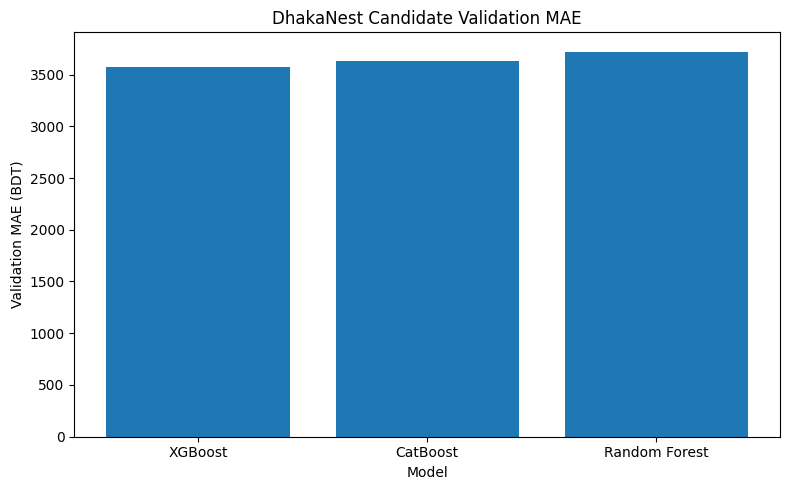

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/comparison/candidate_validation_mae.png


In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    validation_comparison_df["model"],
    validation_comparison_df[
        "validation_mae_bdt"
    ],
)

plt.ylabel("Validation MAE (BDT)")
plt.xlabel("Model")
plt.title(
    "DhakaNest Candidate Validation MAE"
)

plt.tight_layout()

VALIDATION_MAE_FIGURE_PATH = (
    COMPARISON_FIGURES_DIR
    / "candidate_validation_mae.png"
)

plt.savefig(
    VALIDATION_MAE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", VALIDATION_MAE_FIGURE_PATH)

In [16]:
winning_model_name = str(
    validation_comparison_df.iloc[0][
        "model"
    ]
)

winning_validation_mae = float(
    validation_comparison_df.iloc[0][
        "validation_mae_bdt"
    ]
)

assert winning_model_name == "XGBoost", (
    "The expected validation winner was not XGBoost. "
    "Review the candidate metric files before continuing."
)

print("Winning algorithm:", winning_model_name)
print(
    "Winning validation MAE:",
    round(
        winning_validation_mae,
        2,
    ),
)

Winning algorithm: XGBoost
Winning validation MAE: 3571.57


In [17]:
WINNER_SELECTION_PATH = (
    MANIFESTS_DIR
    / "winner_selection_manifest.json"
)

winner_selection_manifest = {
    "project_name": "DhakaNest",
    "selection_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "selection_dataset": "validation.csv",
    "primary_selection_metric": (
        "validation_mae_bdt"
    ),
    "tie_breakers": [
        "validation_rmse_bdt",
        "validation_r2",
    ],
    "winning_model": (
        winning_model_name
    ),
    "winning_validation_mae_bdt": (
        winning_validation_mae
    ),
    "candidate_ranking": (
        validation_comparison_df[
            [
                "model",
                "validation_mae_bdt",
                "validation_rmse_bdt",
                "validation_r2",
                "validation_mape_percent",
            ]
        ].to_dict(
            orient="records"
        )
    ),
    "official_test_loaded": False,
    "official_test_used_for_selection": False,
    "selection_locked": True,
}

save_json(
    winner_selection_manifest,
    WINNER_SELECTION_PATH,
)

print("Winner selection locked.")
print("Saved:", WINNER_SELECTION_PATH)

Winner selection locked.
Saved: /content/drive/MyDrive/DhakaNest_ML/manifests/winner_selection_manifest.json


In [18]:
CATEGORICAL_FEATURES = [
    "broad_area",
    "model_micro_area",
]

NUMERICAL_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

FEATURE_COLUMNS = (
    CATEGORICAL_FEATURES
    + NUMERICAL_FEATURES
)

TARGET_COLUMN = "base_rent_bdt"
GROUP_COLUMN = "duplicate_group_id"

print("Features:", FEATURE_COLUMNS)
print("Target:", TARGET_COLUMN)

Features: ['broad_area', 'model_micro_area', 'area_sqft', 'bedrooms', 'bathrooms']
Target: base_rent_bdt


## Official Test Evaluation

The winning algorithm has already been selected and recorded. The official
test dataset is now loaded for one final unbiased evaluation of the selected
XGBoost candidate.

The test result will be reported but will not be used to change the winning
algorithm or retune its hyperparameters.

In [19]:
test_access_timestamp_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)

test_df = pd.read_csv(TEST_PATH)

print("Official test shape:", test_df.shape)

Official test shape: (2291, 11)


In [20]:
required_test_columns = [
    "record_id",
    "location_raw",
    "broad_area",
    "micro_area",
    "model_micro_area",
    "micro_area_support_count",
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "base_rent_bdt",
    "duplicate_group_id",
]

missing_test_columns = [
    column
    for column in required_test_columns
    if column not in test_df.columns
]

if missing_test_columns:
    raise ValueError(
        "Test set is missing columns: "
        f"{missing_test_columns}"
    )

if test_df[
    FEATURE_COLUMNS + [TARGET_COLUMN]
].isna().any().any():
    raise ValueError(
        "Test set contains missing model values."
    )

if (
    test_df[
        NUMERICAL_FEATURES
        + [TARGET_COLUMN]
    ] <= 0
).any().any():
    raise ValueError(
        "Test set contains non-positive values."
    )

assert len(test_df) == 2291

print("Official test schema validation passed.")

Official test schema validation passed.


In [21]:
xgb_feature_schema = load_json(
    XGB_FEATURE_SCHEMA_PATH
)

xgb_best_parameters = load_json(
    XGB_BEST_PARAMETERS_PATH
)

candidate_target_strategy = (
    xgb_feature_schema[
        "target_strategy"
    ]
)

assert candidate_target_strategy == "log1p"

candidate_preprocessor = joblib.load(
    XGB_CANDIDATE_PREPROCESSOR_PATH
)

candidate_xgb_model = (
    xgb.XGBRegressor()
)

candidate_xgb_model.load_model(
    str(
        XGB_CANDIDATE_MODEL_PATH
    )
)

print(
    "Candidate target strategy:",
    candidate_target_strategy,
)

print(
    "Loaded candidate best iteration:",
    getattr(
        candidate_xgb_model,
        "best_iteration",
        None,
    ),
)

Candidate target strategy: log1p
Loaded candidate best iteration: 467


In [22]:
def convert_predictions_to_bdt(
    predictions,
    target_strategy,
):
    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    if target_strategy == "log1p":
        predictions = np.expm1(
            predictions
        )

    return np.maximum(
        predictions,
        0,
    )


def calculate_regression_metrics(
    y_true,
    y_pred,
):
    y_true_array = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred_array = np.asarray(
        y_pred,
        dtype=float,
    )

    absolute_errors = np.abs(
        y_true_array
        - y_pred_array
    )

    return {
        "mae_bdt": float(
            mean_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "rmse_bdt": float(
            np.sqrt(
                mean_squared_error(
                    y_true_array,
                    y_pred_array,
                )
            )
        ),
        "r2": float(
            r2_score(
                y_true_array,
                y_pred_array,
            )
        ),
        "mape_percent": float(
            mean_absolute_percentage_error(
                y_true_array,
                y_pred_array,
            )
            * 100
        ),
        "median_absolute_error_bdt": float(
            median_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "p90_absolute_error_bdt": float(
            np.percentile(
                absolute_errors,
                90,
            )
        ),
    }

In [23]:
X_test = test_df[
    FEATURE_COLUMNS
].copy()

y_test = test_df[
    TARGET_COLUMN
].copy()

X_test_encoded = (
    candidate_preprocessor.transform(
        X_test
    )
)

test_prediction_start = perf_counter()

test_raw_predictions = (
    candidate_xgb_model.predict(
        X_test_encoded
    )
)

test_prediction_seconds = (
    perf_counter()
    - test_prediction_start
)

test_predictions_bdt = (
    convert_predictions_to_bdt(
        test_raw_predictions,
        candidate_target_strategy,
    )
)

official_test_metrics = (
    calculate_regression_metrics(
        y_test,
        test_predictions_bdt,
    )
)

official_test_metrics[
    "prediction_time_seconds"
] = float(
    test_prediction_seconds
)

official_test_metrics[
    "milliseconds_per_record"
] = float(
    test_prediction_seconds
    / len(test_df)
    * 1000
)

print("Official XGBoost test metrics:")

display(
    pd.DataFrame([
        official_test_metrics
    ])
)

Official XGBoost test metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3193.692559,7667.502101,0.900087,11.883525,1594.668302,6070.577794,0.154332,0.067364


In [24]:
official_test_results_df = test_df[
    [
        "record_id",
        "location_raw",
        "broad_area",
        "micro_area",
        "model_micro_area",
        "micro_area_support_count",
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "base_rent_bdt",
    ]
].copy()

official_test_results_df[
    "predicted_rent_bdt"
] = test_predictions_bdt

official_test_results_df[
    "residual_bdt"
] = (
    official_test_results_df[
        "base_rent_bdt"
    ]
    - official_test_results_df[
        "predicted_rent_bdt"
    ]
)

official_test_results_df[
    "absolute_error_bdt"
] = official_test_results_df[
    "residual_bdt"
].abs()

official_test_results_df[
    "absolute_percentage_error"
] = (
    official_test_results_df[
        "absolute_error_bdt"
    ]
    / official_test_results_df[
        "base_rent_bdt"
    ]
    * 100
)

OFFICIAL_TEST_PREDICTIONS_PATH = (
    METRICS_DIR
    / "xgboost_official_test_predictions.csv"
)

official_test_results_df.to_csv(
    OFFICIAL_TEST_PREDICTIONS_PATH,
    index=False,
)

print(
    "Saved:",
    OFFICIAL_TEST_PREDICTIONS_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_official_test_predictions.csv


In [25]:
OFFICIAL_TEST_METRICS_PATH = (
    METRICS_DIR
    / "xgboost_official_test_metrics.json"
)

official_test_metrics_export = {
    "project_name": "DhakaNest",
    "model_name": "XGBoost",
    "candidate_version": "1.0.0",
    "target_strategy": (
        candidate_target_strategy
    ),
    "test_rows": int(
        len(test_df)
    ),
    "test_accessed_at_utc": (
        test_access_timestamp_utc
    ),
    "winner_locked_before_test": True,
    "test_used_for_model_selection": False,
    "test_used_for_tuning": False,
    "candidate_model_sha256": (
        actual_xgb_model_checksum
    ),
    "metrics": official_test_metrics,
}

save_json(
    official_test_metrics_export,
    OFFICIAL_TEST_METRICS_PATH,
)

print(
    json.dumps(
        official_test_metrics_export,
        indent=2,
    )
)

print(
    "Saved:",
    OFFICIAL_TEST_METRICS_PATH,
)

{
  "project_name": "DhakaNest",
  "model_name": "XGBoost",
  "candidate_version": "1.0.0",
  "target_strategy": "log1p",
  "test_rows": 2291,
  "test_accessed_at_utc": "2026-07-31T09:37:47.153069+00:00",
  "winner_locked_before_test": true,
  "test_used_for_model_selection": false,
  "test_used_for_tuning": false,
  "candidate_model_sha256": "df6e32779624e35f06e926faa6bdd9ee07317e8f4606d20661d1be47cd60cc5e",
  "metrics": {
    "mae_bdt": 3193.6925590871465,
    "rmse_bdt": 7667.502100825346,
    "r2": 0.9000871520980268,
    "mape_percent": 11.88352547382473,
    "median_absolute_error_bdt": 1594.6683021346034,
    "p90_absolute_error_bdt": 6070.577794003042,
    "prediction_time_seconds": 0.15433161200007817,
    "milliseconds_per_record": 0.06736430030557755
  }
}
Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_official_test_metrics.json


In [26]:
TEST_EVALUATION_MANIFEST_PATH = (
    MANIFESTS_DIR
    / "official_test_evaluation_manifest.json"
)

test_evaluation_manifest = {
    "project_name": "DhakaNest",
    "selected_model": "XGBoost",
    "selection_manifest": (
        WINNER_SELECTION_PATH.name
    ),
    "test_file": str(TEST_PATH),
    "test_file_sha256": (
        calculate_sha256(TEST_PATH)
    ),
    "test_rows": int(len(test_df)),
    "first_access_at_utc": (
        test_access_timestamp_utc
    ),
    "official_evaluation_count": 1,
    "test_used_for_model_selection": False,
    "test_used_for_hyperparameter_tuning": False,
    "metrics_file": (
        OFFICIAL_TEST_METRICS_PATH.name
    ),
    "predictions_file": (
        OFFICIAL_TEST_PREDICTIONS_PATH.name
    ),
}

save_json(
    test_evaluation_manifest,
    TEST_EVALUATION_MANIFEST_PATH,
)

print(
    "Saved:",
    TEST_EVALUATION_MANIFEST_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/manifests/official_test_evaluation_manifest.json


In [27]:
xgb_validation_metrics = (
    xgb_metrics[
        "chosen_candidate"
    ]["validation"]
)

validation_test_comparison_df = (
    pd.DataFrame([
        {
            "dataset": "Validation",
            "mae_bdt": (
                xgb_validation_metrics[
                    "mae_bdt"
                ]
            ),
            "rmse_bdt": (
                xgb_validation_metrics[
                    "rmse_bdt"
                ]
            ),
            "r2": (
                xgb_validation_metrics[
                    "r2"
                ]
            ),
            "mape_percent": (
                xgb_validation_metrics[
                    "mape_percent"
                ]
            ),
            "median_absolute_error_bdt": (
                xgb_validation_metrics[
                    "median_absolute_error_bdt"
                ]
            ),
            "p90_absolute_error_bdt": (
                xgb_validation_metrics[
                    "p90_absolute_error_bdt"
                ]
            ),
        },
        {
            "dataset": "Official Test",
            "mae_bdt": (
                official_test_metrics[
                    "mae_bdt"
                ]
            ),
            "rmse_bdt": (
                official_test_metrics[
                    "rmse_bdt"
                ]
            ),
            "r2": (
                official_test_metrics[
                    "r2"
                ]
            ),
            "mape_percent": (
                official_test_metrics[
                    "mape_percent"
                ]
            ),
            "median_absolute_error_bdt": (
                official_test_metrics[
                    "median_absolute_error_bdt"
                ]
            ),
            "p90_absolute_error_bdt": (
                official_test_metrics[
                    "p90_absolute_error_bdt"
                ]
            ),
        },
    ])
)

VALIDATION_TEST_COMPARISON_PATH = (
    METRICS_DIR
    / "xgboost_validation_vs_test.csv"
)

validation_test_comparison_df.to_csv(
    VALIDATION_TEST_COMPARISON_PATH,
    index=False,
)

display(validation_test_comparison_df)

print(
    "Saved:",
    VALIDATION_TEST_COMPARISON_PATH,
)

,dataset,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Validation,3571.573025,8842.536408,0.841546,12.681240,1689.224844,6454.955466
1,Official Test,3193.692559,7667.502101,0.900087,11.883525,1594.668302,6070.577794


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_validation_vs_test.csv


In [28]:
validation_mae = float(
    xgb_validation_metrics[
        "mae_bdt"
    ]
)

test_mae = float(
    official_test_metrics[
        "mae_bdt"
    ]
)

mae_difference_bdt = (
    test_mae
    - validation_mae
)

mae_difference_percent = (
    mae_difference_bdt
    / validation_mae
    * 100
)

print(
    "Validation MAE:",
    round(validation_mae, 2),
)

print(
    "Official test MAE:",
    round(test_mae, 2),
)

print(
    "Test minus validation MAE:",
    round(mae_difference_bdt, 2),
)

print(
    "Percentage change:",
    round(mae_difference_percent, 2),
    "%",
)

Validation MAE: 3571.57
Official test MAE: 3193.69
Test minus validation MAE: -377.88
Percentage change: -10.58 %


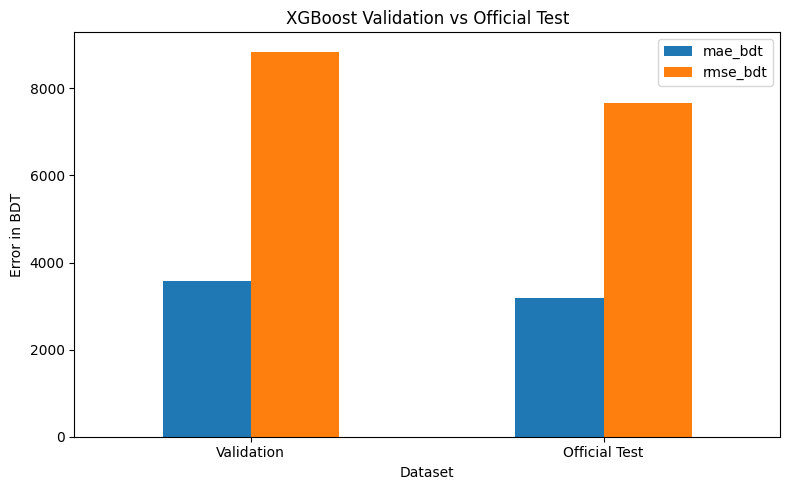

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/comparison/xgboost_validation_vs_test.png


In [29]:
metric_plot_df = (
    validation_test_comparison_df[
        [
            "dataset",
            "mae_bdt",
            "rmse_bdt",
        ]
    ]
    .set_index("dataset")
)

metric_plot_df.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.ylabel("Error in BDT")
plt.xlabel("Dataset")
plt.title(
    "XGBoost Validation vs Official Test"
)

plt.xticks(rotation=0)
plt.tight_layout()

VALIDATION_TEST_FIGURE_PATH = (
    COMPARISON_FIGURES_DIR
    / "xgboost_validation_vs_test.png"
)

plt.savefig(
    VALIDATION_TEST_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", VALIDATION_TEST_FIGURE_PATH)

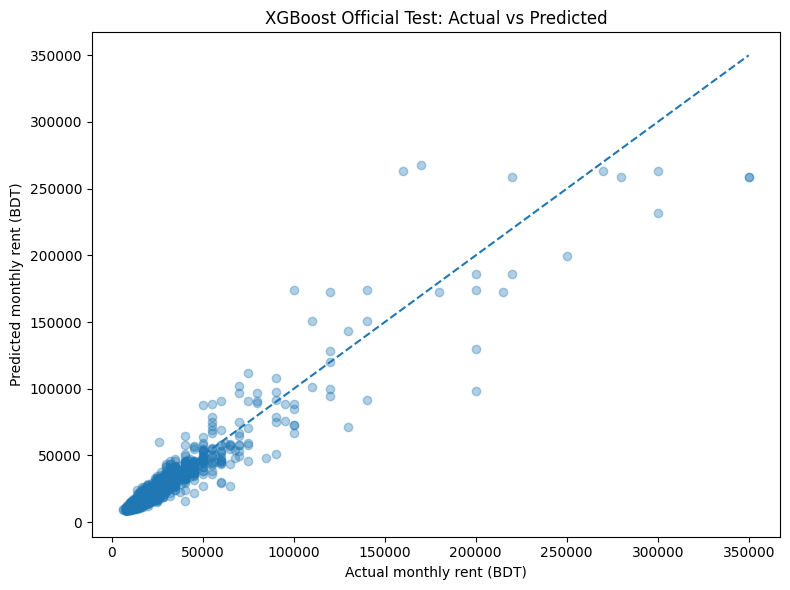

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/comparison/official_test_actual_vs_predicted.png


In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    official_test_results_df[
        "base_rent_bdt"
    ],
    official_test_results_df[
        "predicted_rent_bdt"
    ],
    alpha=0.35,
)

minimum_value = min(
    official_test_results_df[
        "base_rent_bdt"
    ].min(),
    official_test_results_df[
        "predicted_rent_bdt"
    ].min(),
)

maximum_value = max(
    official_test_results_df[
        "base_rent_bdt"
    ].max(),
    official_test_results_df[
        "predicted_rent_bdt"
    ].max(),
)

plt.plot(
    [
        minimum_value,
        maximum_value,
    ],
    [
        minimum_value,
        maximum_value,
    ],
    linestyle="--",
)

plt.xlabel("Actual monthly rent (BDT)")
plt.ylabel("Predicted monthly rent (BDT)")

plt.title(
    "XGBoost Official Test: Actual vs Predicted"
)

plt.tight_layout()

TEST_ACTUAL_PREDICTED_PATH = (
    COMPARISON_FIGURES_DIR
    / "official_test_actual_vs_predicted.png"
)

plt.savefig(
    TEST_ACTUAL_PREDICTED_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", TEST_ACTUAL_PREDICTED_PATH)

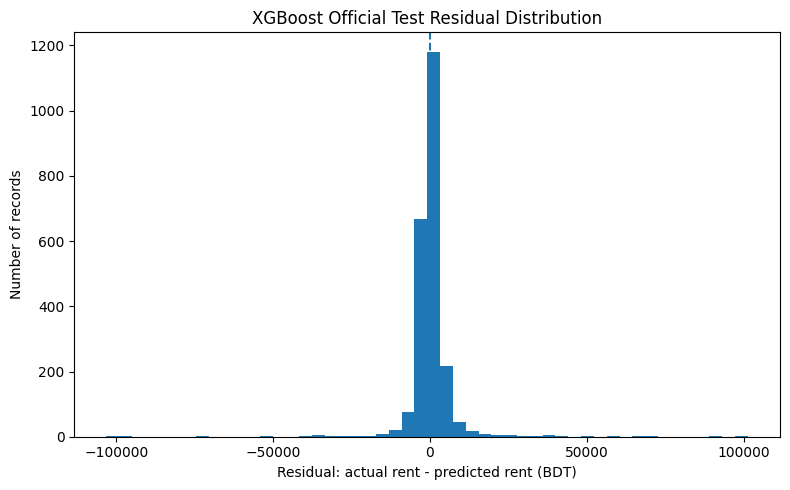

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/comparison/official_test_residual_distribution.png


In [31]:
plt.figure(figsize=(8, 5))

plt.hist(
    official_test_results_df[
        "residual_bdt"
    ],
    bins=50,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel(
    "Residual: actual rent - predicted rent (BDT)"
)

plt.ylabel("Number of records")

plt.title(
    "XGBoost Official Test Residual Distribution"
)

plt.tight_layout()

TEST_RESIDUAL_PATH = (
    COMPARISON_FIGURES_DIR
    / "official_test_residual_distribution.png"
)

plt.savefig(
    TEST_RESIDUAL_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", TEST_RESIDUAL_PATH)

In [32]:
largest_test_errors_df = (
    official_test_results_df
    .sort_values(
        "absolute_error_bdt",
        ascending=False,
    )
    .head(30)
)

LARGEST_TEST_ERRORS_PATH = (
    METRICS_DIR
    / "xgboost_largest_official_test_errors.csv"
)

largest_test_errors_df.to_csv(
    LARGEST_TEST_ERRORS_PATH,
    index=False,
)

display(
    largest_test_errors_df[
        [
            "record_id",
            "location_raw",
            "area_sqft",
            "bedrooms",
            "bathrooms",
            "base_rent_bdt",
            "predicted_rent_bdt",
            "absolute_error_bdt",
            "absolute_percentage_error",
        ]
    ]
)

print("Saved:", LARGEST_TEST_ERRORS_PATH)

,record_id,location_raw,area_sqft,bedrooms,bathrooms,base_rent_bdt,predicted_rent_bdt,absolute_error_bdt,absolute_percentage_error
175,DN-001510,"Baridhara, Dhaka",4138,4,4,160000,263169.764566,103169.764566,64.481103
103,DN-000911,"Gulshan 1, Gulshan, Dhaka",2500,4,3,200000,98604.121261,101395.878739,50.697939
2177,DN-026999,"Gulshan 2, Gulshan, Dhaka",3554,4,5,170000,267506.388586,97506.388586,57.356699
158,DN-001410,"Gulshan 2, Gulshan, Dhaka",3500,4,4,350000,258896.776060,91103.223940,26.029493
64,DN-000557,"Gulshan 2, Gulshan, Dhaka",5000,4,4,350000,258896.776060,91103.223940,26.029493
142,DN-001260,"Baridhara, Dhaka",3300,4,4,100000,173920.865294,73920.865294,73.920865
127,DN-001115,"Gulshan 2, Gulshan, Dhaka",3000,4,3,200000,130090.874688,69909.125312,34.954563
53,DN-000448,"Gulshan 2, Gulshan, Dhaka",3800,3,4,300000,231492.777550,68507.222450,22.835741
185,DN-001586,"Sector 1, Uttara, Dhaka",3000,4,4,130000,71570.382293,58429.617707,44.945860
1190,DN-013320,"Baridhara, Dhaka",3000,3,4,120000,172498.780867,52498.780867,43.748984


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_largest_official_test_errors.csv


In [33]:
official_test_results_df[
    "micro_area_support_level"
] = pd.cut(
    official_test_results_df[
        "micro_area_support_count"
    ],
    bins=[
        -np.inf,
        29,
        99,
        np.inf,
    ],
    labels=[
        "low",
        "normal",
        "high",
    ],
)

official_test_results_df[
    "rent_range"
] = pd.cut(
    official_test_results_df[
        "base_rent_bdt"
    ],
    bins=[
        -np.inf,
        15_000,
        30_000,
        60_000,
        np.inf,
    ],
    labels=[
        "below_15000",
        "15000_to_30000",
        "30001_to_60000",
        "above_60000",
    ],
)

official_test_results_df[
    "area_range"
] = pd.cut(
    official_test_results_df[
        "area_sqft"
    ],
    bins=[
        -np.inf,
        700,
        1000,
        1500,
        2500,
        np.inf,
    ],
    labels=[
        "up_to_700",
        "701_to_1000",
        "1001_to_1500",
        "1501_to_2500",
        "above_2500",
    ],
)

print("Official test segments created.")

Official test segments created.


In [34]:
def calculate_segment_metrics(
    dataframe,
    segment_column,
):
    rows = []

    for segment_value, group in (
        dataframe.groupby(
            segment_column,
            dropna=False,
            observed=False,
        )
    ):
        if len(group) == 0:
            continue

        metrics = calculate_regression_metrics(
            group["base_rent_bdt"],
            group["predicted_rent_bdt"],
        )

        rows.append({
            "segment": str(
                segment_value
            ),
            "record_count": int(
                len(group)
            ),
            **metrics,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "mae_bdt",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [35]:
test_segment_definitions = {
    "broad_area": "broad_area",
    "model_micro_area": (
        "model_micro_area"
    ),
    "micro_area_support": (
        "micro_area_support_level"
    ),
    "bedroom_count": "bedrooms",
    "bathroom_count": "bathrooms",
    "rent_range": "rent_range",
    "area_range": "area_range",
}

official_test_segment_tables = {}

for output_name, segment_column in (
    test_segment_definitions.items()
):
    result_df = (
        calculate_segment_metrics(
            official_test_results_df,
            segment_column,
        )
    )

    official_test_segment_tables[
        output_name
    ] = result_df

    output_path = (
        SEGMENT_DIR
        / f"xgboost_test_by_{output_name}.csv"
    )

    result_df.to_csv(
        output_path,
        index=False,
    )

    print("\nSegment:", output_name)
    display(result_df.head(20))
    print("Saved:", output_path)


Segment: broad_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Gulshan,25,34218.302259,46667.345654,0.744919,25.880676,21103.223940,91103.223940
1,Baridhara,22,33057.349381,40452.969751,0.680378,26.994287,32247.708194,52308.344318
2,Mohakhali DOHS,1,15878.404910,15878.404910,NaN,39.696012,15878.404910,15878.404910
3,Baridhara DOHS,7,14280.117426,15801.821441,0.321925,25.009531,13659.971280,20340.466220
4,Banani,17,8917.985582,11047.734620,0.627724,14.314578,8467.664474,17211.023344
5,Kakrail,3,8254.748744,9058.087694,0.952815,13.236098,7453.613736,12026.579337
6,Lalmatia,9,7337.360172,8355.944682,0.655121,18.676413,5973.960252,11076.614903
7,Niketan,5,5751.361871,6584.860591,-3.075225,17.233097,5326.268304,9334.650411
8,Paribagh,1,5623.737641,5623.737641,NaN,16.067822,5623.737641,5623.737641
9,Bashundhara R/A,132,5510.042459,8909.049793,0.663741,14.987971,3168.377756,13162.191822


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_test_by_broad_area.csv

Segment: model_micro_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Baridhara,15,38543.465695,45338.077760,0.588746,32.729900,36830.235434,65352.031523
1,Gulshan 2,15,37801.597948,50999.999283,0.725421,19.035972,20282.921148,91103.223940
2,Gulshan 1,10,28843.358725,39282.349542,0.183651,36.147732,25541.028550,43928.913774
3,Block K,6,23486.525766,29159.150316,0.692679,12.098410,23737.566612,42339.616169
4,Sector 1,5,18087.747319,27499.289807,0.393089,22.396752,9066.879757,41241.007376
5,OTHER_MOHAKHALI_DOHS,1,15878.404910,15878.404910,NaN,39.696012,15878.404910,15878.404910
6,Baridhara DOHS,7,14280.117426,15801.821441,0.321925,25.009531,13659.971280,20340.466220
7,Sector 3,11,11474.769627,13157.184891,-0.272106,28.656173,10326.295671,21467.798343
8,Block A,15,10690.289277,16726.344092,0.312652,21.015027,5415.559581,34189.140170
9,OTHER_LALMATIA,2,10563.645079,12054.240658,-1.532296,18.893517,10563.645079,15208.754024


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_test_by_model_micro_area.csv

Segment: micro_area_support


...

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_test_by_bathroom_count.csv

Segment: rent_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_60000,72,27737.612247,37443.555506,0.733335,22.706721,18785.069282,67499.461975
1,30001_to_60000,237,6618.420012,9088.167011,-0.174040,15.263128,4976.878575,13732.609228
2,15000_to_30000,1065,2394.225453,3269.083633,0.365105,11.264660,1879.160747,5020.330200
3,below_15000,917,1309.951931,1743.437448,0.195494,10.879006,1018.398567,2840.659032


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_test_by_rent_range.csv

Segment: area_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_2500,52,28431.969224,38997.415310,0.783679,22.648110,17688.470055,69768.935026
1,1501_to_2500,299,7059.470849,11514.472452,0.674530,16.160674,4792.440532,13926.457054
2,1001_to_1500,746,2488.789735,3662.813485,0.684020,11.123053,1819.184978,5249.822474
3,701_to_1000,653,1792.546868,2584.810189,0.549469,11.086448,1343.127096,3702.462041
4,up_to_700,541,1294.519819,1716.529593,0.602805,10.495685,1018.398567,2804.560947


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_test_by_area_range.csv


## Production Retraining

The official test evaluation is complete.

The production model is now retrained using the combined training and
validation datasets. The test dataset is not included.

The selected hyperparameters, target strategy, and number of boosting rounds
remain fixed. The official test result is not used to change them.

In [36]:
train_df = pd.read_csv(TRAIN_PATH)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

combined_training_df = (
    pd.concat(
        [
            train_df,
            validation_df,
        ],
        ignore_index=True,
    )
)

print("Training rows:", len(train_df))
print(
    "Validation rows:",
    len(validation_df),
)
print(
    "Combined production-training rows:",
    len(combined_training_df),
)

Training rows: 10668
Validation rows: 2289
Combined production-training rows: 12957


In [37]:
assert len(combined_training_df) == 12957

assert (
    combined_training_df[
        "record_id"
    ].nunique()
    == len(combined_training_df)
), "Duplicate record IDs in combined training data."

assert set(
    combined_training_df[
        "record_id"
    ]
).isdisjoint(
    set(test_df["record_id"])
), "Test records entered production training."

assert set(
    combined_training_df[
        GROUP_COLUMN
    ]
).isdisjoint(
    set(test_df[GROUP_COLUMN])
), "Test duplicate groups entered production training."

print("Combined production-training integrity passed.")

Combined production-training integrity passed.


In [38]:
best_core_parameters = (
    xgb_best_parameters[
        "best_core_parameters"
    ]
)

effective_n_estimators = int(
    xgb_best_parameters[
        "selected_effective_estimators"
    ]
)

production_target_strategy = (
    xgb_best_parameters[
        "target_strategy"
    ]
)

assert production_target_strategy == "log1p"

print(
    "Production target strategy:",
    production_target_strategy,
)

print(
    "Fixed production estimators:",
    effective_n_estimators,
)

display(
    pd.DataFrame(
        list(
            best_core_parameters.items()
        ),
        columns=[
            "parameter",
            "value",
        ],
    )
)

Production target strategy: log1p
Fixed production estimators: 468


,parameter,value
0,subsample,0.85
1,reg_lambda,1.00
2,reg_alpha,0.00
3,min_child_weight,10.00
4,max_depth,7.00
5,learning_rate,0.06
6,gamma,0.00
7,colsample_bytree,0.70


In [39]:
def create_preprocessor(
    categorical_features,
    numerical_features,
):
    transformers = []

    if categorical_features:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True,
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features,
            )
        )

    if numerical_features:
        numerical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_features,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
    )

In [40]:
def train_production_xgb_bundle(
    dataframe,
    feature_columns,
    categorical_features,
    numerical_features,
):
    preprocessor = create_preprocessor(
        categorical_features=(
            categorical_features
        ),
        numerical_features=(
            numerical_features
        ),
    )

    X = dataframe[
        feature_columns
    ].copy()

    y = dataframe[
        TARGET_COLUMN
    ].astype(float)

    X_encoded = (
        preprocessor.fit_transform(X)
    )

    if production_target_strategy == "log1p":
        fitted_target = np.log1p(
            y.to_numpy()
        )
    else:
        fitted_target = y.to_numpy()

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=(
            effective_n_estimators
        ),
        tree_method="hist",
        eval_metric="mae",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **best_core_parameters,
    )

    training_start = perf_counter()

    model.fit(
        X_encoded,
        fitted_target,
        verbose=False,
    )

    training_seconds = (
        perf_counter()
        - training_start
    )

    encoded_feature_names = (
        preprocessor.get_feature_names_out()
    )

    return {
        "model": model,
        "preprocessor": preprocessor,
        "feature_columns": feature_columns,
        "categorical_features": (
            categorical_features
        ),
        "numerical_features": (
            numerical_features
        ),
        "encoded_feature_names": (
            encoded_feature_names
        ),
        "training_seconds": float(
            training_seconds
        ),
    }

In [41]:
primary_bundle = (
    train_production_xgb_bundle(
        dataframe=combined_training_df,
        feature_columns=FEATURE_COLUMNS,
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        numerical_features=(
            NUMERICAL_FEATURES
        ),
    )
)

print(
    "Primary production model trained."
)

print(
    "Training seconds:",
    round(
        primary_bundle[
            "training_seconds"
        ],
        2,
    ),
)

print(
    "Encoded features:",
    len(
        primary_bundle[
            "encoded_feature_names"
        ]
    ),
)

Primary production model trained.
Training seconds: 8.09
Encoded features: 269


In [42]:
BROAD_FALLBACK_FEATURES = [
    "broad_area",
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

broad_fallback_bundle = (
    train_production_xgb_bundle(
        dataframe=combined_training_df,
        feature_columns=(
            BROAD_FALLBACK_FEATURES
        ),
        categorical_features=[
            "broad_area"
        ],
        numerical_features=(
            NUMERICAL_FEATURES
        ),
    )
)

print(
    "Broad-area fallback trained."
)

print(
    "Training seconds:",
    round(
        broad_fallback_bundle[
            "training_seconds"
        ],
        2,
    ),
)

Broad-area fallback trained.
Training seconds: 1.71


In [43]:
DHAKA_WIDE_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

dhaka_wide_bundle = (
    train_production_xgb_bundle(
        dataframe=combined_training_df,
        feature_columns=(
            DHAKA_WIDE_FEATURES
        ),
        categorical_features=[],
        numerical_features=(
            NUMERICAL_FEATURES
        ),
    )
)

print(
    "Dhaka-wide fallback trained."
)

print(
    "Training seconds:",
    round(
        dhaka_wide_bundle[
            "training_seconds"
        ],
        2,
    ),
)

Dhaka-wide fallback trained.
Training seconds: 1.83


In [44]:
PRIMARY_MODEL_PATH = (
    PRIMARY_MODEL_DIR
    / "xgboost_primary_model.json"
)

PRIMARY_PREPROCESSOR_PATH = (
    PRIMARY_MODEL_DIR
    / "primary_preprocessor.joblib"
)

PRIMARY_FEATURE_NAMES_PATH = (
    PRIMARY_MODEL_DIR
    / "primary_encoded_feature_names.csv"
)

BROAD_MODEL_PATH = (
    FALLBACK_MODEL_DIR
    / "xgboost_broad_area_model.json"
)

BROAD_PREPROCESSOR_PATH = (
    FALLBACK_MODEL_DIR
    / "broad_area_preprocessor.joblib"
)

BROAD_FEATURE_NAMES_PATH = (
    FALLBACK_MODEL_DIR
    / "broad_area_encoded_feature_names.csv"
)

DHAKA_MODEL_PATH = (
    FALLBACK_MODEL_DIR
    / "xgboost_dhaka_wide_model.json"
)

DHAKA_PREPROCESSOR_PATH = (
    FALLBACK_MODEL_DIR
    / "dhaka_wide_preprocessor.joblib"
)

DHAKA_FEATURE_NAMES_PATH = (
    FALLBACK_MODEL_DIR
    / "dhaka_wide_encoded_feature_names.csv"
)

In [45]:
primary_bundle["model"].save_model(
    str(PRIMARY_MODEL_PATH)
)

joblib.dump(
    primary_bundle["preprocessor"],
    PRIMARY_PREPROCESSOR_PATH,
    compress=3,
)

pd.DataFrame({
    "feature": (
        primary_bundle[
            "encoded_feature_names"
        ]
    )
}).to_csv(
    PRIMARY_FEATURE_NAMES_PATH,
    index=False,
)

print("Saved:", PRIMARY_MODEL_PATH)
print("Saved:", PRIMARY_PREPROCESSOR_PATH)
print("Saved:", PRIMARY_FEATURE_NAMES_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/primary_model/xgboost_primary_model.json
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/primary_model/primary_preprocessor.joblib
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/primary_model/primary_encoded_feature_names.csv


In [46]:
broad_fallback_bundle[
    "model"
].save_model(
    str(BROAD_MODEL_PATH)
)

joblib.dump(
    broad_fallback_bundle[
        "preprocessor"
    ],
    BROAD_PREPROCESSOR_PATH,
    compress=3,
)

pd.DataFrame({
    "feature": (
        broad_fallback_bundle[
            "encoded_feature_names"
        ]
    )
}).to_csv(
    BROAD_FEATURE_NAMES_PATH,
    index=False,
)

dhaka_wide_bundle[
    "model"
].save_model(
    str(DHAKA_MODEL_PATH)
)

joblib.dump(
    dhaka_wide_bundle[
        "preprocessor"
    ],
    DHAKA_PREPROCESSOR_PATH,
    compress=3,
)

pd.DataFrame({
    "feature": (
        dhaka_wide_bundle[
            "encoded_feature_names"
        ]
    )
}).to_csv(
    DHAKA_FEATURE_NAMES_PATH,
    index=False,
)

print("Saved:", BROAD_MODEL_PATH)
print("Saved:", BROAD_PREPROCESSOR_PATH)
print("Saved:", DHAKA_MODEL_PATH)
print("Saved:", DHAKA_PREPROCESSOR_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/fallback_models/xgboost_broad_area_model.json
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/fallback_models/broad_area_preprocessor.joblib
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/fallback_models/xgboost_dhaka_wide_model.json
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/fallback_models/dhaka_wide_preprocessor.joblib


In [47]:
known_broad_areas = sorted(
    combined_training_df[
        "broad_area"
    ]
    .astype(str)
    .unique()
    .tolist()
)

known_model_micro_areas = sorted(
    combined_training_df[
        "model_micro_area"
    ]
    .astype(str)
    .unique()
    .tolist()
)

routing_reference = {
    "routing_version": "1.0.0",
    "primary_features": (
        FEATURE_COLUMNS
    ),
    "broad_area_fallback_features": (
        BROAD_FALLBACK_FEATURES
    ),
    "dhaka_wide_fallback_features": (
        DHAKA_WIDE_FEATURES
    ),
    "known_broad_areas": (
        known_broad_areas
    ),
    "known_model_micro_areas": (
        known_model_micro_areas
    ),
    "routing_rules": [
        {
            "priority": 1,
            "condition": (
                "model_micro_area is in "
                "known_model_micro_areas"
            ),
            "model": "primary",
        },
        {
            "priority": 2,
            "condition": (
                "broad_area is in "
                "known_broad_areas"
            ),
            "model": (
                "broad_area_fallback"
            ),
        },
        {
            "priority": 3,
            "condition": "otherwise",
            "model": (
                "dhaka_wide_fallback"
            ),
        },
    ],
}

ROUTING_REFERENCE_PATH = (
    BUNDLE_METADATA_DIR
    / "routing_reference.json"
)

save_json(
    routing_reference,
    ROUTING_REFERENCE_PATH,
)

print("Known broad areas:", len(known_broad_areas))

print(
    "Known model micro-areas:",
    len(known_model_micro_areas),
)

print("Saved:", ROUTING_REFERENCE_PATH)

Known broad areas: 68
Known model micro-areas: 198
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/metadata/routing_reference.json


In [48]:
production_feature_schema = {
    "project_name": "DhakaNest",
    "model_name": "XGBoost",
    "bundle_version": "1.0.0",
    "target_column": TARGET_COLUMN,
    "target_strategy": (
        production_target_strategy
    ),
    "currency": "BDT",
    "primary_model": {
        "feature_order": (
            FEATURE_COLUMNS
        ),
        "categorical_features": (
            CATEGORICAL_FEATURES
        ),
        "numerical_features": (
            NUMERICAL_FEATURES
        ),
    },
    "broad_area_fallback": {
        "feature_order": (
            BROAD_FALLBACK_FEATURES
        ),
        "categorical_features": [
            "broad_area"
        ],
        "numerical_features": (
            NUMERICAL_FEATURES
        ),
    },
    "dhaka_wide_fallback": {
        "feature_order": (
            DHAKA_WIDE_FEATURES
        ),
        "categorical_features": [],
        "numerical_features": (
            NUMERICAL_FEATURES
        ),
    },
    "input_validation": {
        "area_sqft": (
            "positive numeric value"
        ),
        "bedrooms": (
            "positive numeric value"
        ),
        "bathrooms": (
            "positive numeric value"
        ),
        "broad_area": (
            "normalized string when available"
        ),
        "model_micro_area": (
            "normalized supported category "
            "when available"
        ),
    },
}

PRODUCTION_FEATURE_SCHEMA_PATH = (
    BUNDLE_METADATA_DIR
    / "feature_schema.json"
)

save_json(
    production_feature_schema,
    PRODUCTION_FEATURE_SCHEMA_PATH,
)

print(
    "Saved:",
    PRODUCTION_FEATURE_SCHEMA_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/metadata/feature_schema.json


In [49]:
sample_input = {
    "broad_area": str(
        validation_df.iloc[0][
            "broad_area"
        ]
    ),
    "model_micro_area": str(
        validation_df.iloc[0][
            "model_micro_area"
        ]
    ),
    "area_sqft": float(
        validation_df.iloc[0][
            "area_sqft"
        ]
    ),
    "bedrooms": float(
        validation_df.iloc[0][
            "bedrooms"
        ]
    ),
    "bathrooms": float(
        validation_df.iloc[0][
            "bathrooms"
        ]
    ),
}

SAMPLE_INPUT_PATH = (
    WINNING_BUNDLE_DIR
    / "sample_input.json"
)

save_json(
    sample_input,
    SAMPLE_INPUT_PATH,
)

print(
    json.dumps(
        sample_input,
        indent=2,
    )
)

print("Saved:", SAMPLE_INPUT_PATH)

{
  "broad_area": "Gulshan",
  "model_micro_area": "Gulshan 1",
  "area_sqft": 2200.0,
  "bedrooms": 3.0,
  "bathrooms": 4.0
}
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/sample_input.json


In [50]:
def predict_with_saved_bundle(
    model,
    preprocessor,
    input_dataframe,
    feature_columns,
):
    encoded = preprocessor.transform(
        input_dataframe[
            feature_columns
        ]
    )

    raw_predictions = model.predict(
        encoded
    )

    return convert_predictions_to_bdt(
        raw_predictions,
        production_target_strategy,
    )

In [51]:
reloaded_primary_preprocessor = (
    joblib.load(
        PRIMARY_PREPROCESSOR_PATH
    )
)

reloaded_primary_model = (
    xgb.XGBRegressor()
)

reloaded_primary_model.load_model(
    str(PRIMARY_MODEL_PATH)
)

sample_input_df = pd.DataFrame([
    sample_input
])

prediction_before_reload = (
    predict_with_saved_bundle(
        model=primary_bundle["model"],
        preprocessor=(
            primary_bundle[
                "preprocessor"
            ]
        ),
        input_dataframe=(
            sample_input_df
        ),
        feature_columns=(
            FEATURE_COLUMNS
        ),
    )[0]
)

prediction_after_reload = (
    predict_with_saved_bundle(
        model=(
            reloaded_primary_model
        ),
        preprocessor=(
            reloaded_primary_preprocessor
        ),
        input_dataframe=(
            sample_input_df
        ),
        feature_columns=(
            FEATURE_COLUMNS
        ),
    )[0]
)

print(
    "Before reload:",
    prediction_before_reload,
)

print(
    "After reload:",
    prediction_after_reload,
)

assert np.isclose(
    prediction_before_reload,
    prediction_after_reload,
    rtol=0,
    atol=1e-6,
)

print("Primary production artifact reload passed.")

Before reload: 70740.32832672827
After reload: 70740.32832672827
Primary production artifact reload passed.


In [52]:
reloaded_broad_preprocessor = (
    joblib.load(
        BROAD_PREPROCESSOR_PATH
    )
)

reloaded_broad_model = (
    xgb.XGBRegressor()
)

reloaded_broad_model.load_model(
    str(BROAD_MODEL_PATH)
)

reloaded_dhaka_preprocessor = (
    joblib.load(
        DHAKA_PREPROCESSOR_PATH
    )
)

reloaded_dhaka_model = (
    xgb.XGBRegressor()
)

reloaded_dhaka_model.load_model(
    str(DHAKA_MODEL_PATH)
)

broad_prediction = (
    predict_with_saved_bundle(
        model=reloaded_broad_model,
        preprocessor=(
            reloaded_broad_preprocessor
        ),
        input_dataframe=sample_input_df,
        feature_columns=(
            BROAD_FALLBACK_FEATURES
        ),
    )[0]
)

dhaka_prediction = (
    predict_with_saved_bundle(
        model=reloaded_dhaka_model,
        preprocessor=(
            reloaded_dhaka_preprocessor
        ),
        input_dataframe=sample_input_df,
        feature_columns=(
            DHAKA_WIDE_FEATURES
        ),
    )[0]
)

print(
    "Primary prediction:",
    round(
        prediction_after_reload,
        2,
    ),
)

print(
    "Broad fallback prediction:",
    round(
        broad_prediction,
        2,
    ),
)

print(
    "Dhaka-wide prediction:",
    round(
        dhaka_prediction,
        2,
    ),
)

assert prediction_after_reload >= 0
assert broad_prediction >= 0
assert dhaka_prediction >= 0

print("Fallback artifact reload checks passed.")

Primary prediction: 70740.33
Broad fallback prediction: 75049.31
Dhaka-wide prediction: 47591.14
Fallback artifact reload checks passed.


In [53]:
INFERENCE_HELPER_PATH = (
    WINNING_BUNDLE_DIR
    / "inference_helper.py"
)

inference_helper_code = textwrap.dedent(
    """
    from pathlib import Path
    import json

    import joblib
    import numpy as np
    import pandas as pd
    import xgboost as xgb


    class DhakaNestRentPredictor:
        def __init__(self, bundle_dir):
            self.bundle_dir = Path(bundle_dir)

            metadata_dir = (
                self.bundle_dir / "metadata"
            )

            primary_dir = (
                self.bundle_dir / "primary_model"
            )

            fallback_dir = (
                self.bundle_dir / "fallback_models"
            )

            with (
                metadata_dir
                / "routing_reference.json"
            ).open(
                "r",
                encoding="utf-8",
            ) as file:
                self.routing = json.load(file)

            with (
                metadata_dir
                / "feature_schema.json"
            ).open(
                "r",
                encoding="utf-8",
            ) as file:
                self.schema = json.load(file)

            self.target_strategy = (
                self.schema["target_strategy"]
            )

            self.known_broad_areas = set(
                self.routing[
                    "known_broad_areas"
                ]
            )

            self.known_model_micro_areas = set(
                self.routing[
                    "known_model_micro_areas"
                ]
            )

            self.primary_features = (
                self.routing[
                    "primary_features"
                ]
            )

            self.broad_features = (
                self.routing[
                    "broad_area_fallback_features"
                ]
            )

            self.dhaka_features = (
                self.routing[
                    "dhaka_wide_fallback_features"
                ]
            )

            self.primary_preprocessor = (
                joblib.load(
                    primary_dir
                    / "primary_preprocessor.joblib"
                )
            )

            self.primary_model = (
                xgb.XGBRegressor()
            )

            self.primary_model.load_model(
                str(
                    primary_dir
                    / "xgboost_primary_model.json"
                )
            )

            self.broad_preprocessor = (
                joblib.load(
                    fallback_dir
                    / "broad_area_preprocessor.joblib"
                )
            )

            self.broad_model = (
                xgb.XGBRegressor()
            )

            self.broad_model.load_model(
                str(
                    fallback_dir
                    / "xgboost_broad_area_model.json"
                )
            )

            self.dhaka_preprocessor = (
                joblib.load(
                    fallback_dir
                    / "dhaka_wide_preprocessor.joblib"
                )
            )

            self.dhaka_model = (
                xgb.XGBRegressor()
            )

            self.dhaka_model.load_model(
                str(
                    fallback_dir
                    / "xgboost_dhaka_wide_model.json"
                )
            )

        @staticmethod
        def _positive_number(
            value,
            field_name,
        ):
            number = float(value)

            if number <= 0:
                raise ValueError(
                    f"{field_name} must be positive."
                )

            return number

        def _prepare_payload(self, payload):
            return {
                "broad_area": str(
                    payload.get(
                        "broad_area",
                        "Unknown",
                    )
                ),
                "model_micro_area": str(
                    payload.get(
                        "model_micro_area",
                        "Unknown",
                    )
                ),
                "area_sqft": (
                    self._positive_number(
                        payload["area_sqft"],
                        "area_sqft",
                    )
                ),
                "bedrooms": (
                    self._positive_number(
                        payload["bedrooms"],
                        "bedrooms",
                    )
                ),
                "bathrooms": (
                    self._positive_number(
                        payload["bathrooms"],
                        "bathrooms",
                    )
                ),
            }

        def _convert_prediction(self, raw_value):
            value = float(raw_value)

            if self.target_strategy == "log1p":
                value = float(
                    np.expm1(value)
                )

            return max(value, 0.0)

        def _predict_model(
            self,
            model,
            preprocessor,
            row,
            feature_columns,
        ):
            dataframe = pd.DataFrame(
                [row]
            )

            encoded = preprocessor.transform(
                dataframe[feature_columns]
            )

            raw_prediction = model.predict(
                encoded
            )[0]

            return self._convert_prediction(
                raw_prediction
            )

        def predict(self, payload):
            row = self._prepare_payload(
                payload
            )

            model_micro_area = (
                row["model_micro_area"]
            )

            broad_area = (
                row["broad_area"]
            )

            if (
                model_micro_area
                in self.known_model_micro_areas
            ):
                route = "primary"

                prediction = (
                    self._predict_model(
                        self.primary_model,
                        self.primary_preprocessor,
                        row,
                        self.primary_features,
                    )
                )

            elif (
                broad_area
                in self.known_broad_areas
            ):
                route = (
                    "broad_area_fallback"
                )

                prediction = (
                    self._predict_model(
                        self.broad_model,
                        self.broad_preprocessor,
                        row,
                        self.broad_features,
                    )
                )

            else:
                route = (
                    "dhaka_wide_fallback"
                )

                prediction = (
                    self._predict_model(
                        self.dhaka_model,
                        self.dhaka_preprocessor,
                        row,
                        self.dhaka_features,
                    )
                )

            return {
                "predicted_rent_bdt": round(
                    prediction,
                    2,
                ),
                "model_route": route,
                "target_strategy": (
                    self.target_strategy
                ),
            }
    """
)

INFERENCE_HELPER_PATH.write_text(
    inference_helper_code,
    encoding="utf-8",
)

print("Saved:", INFERENCE_HELPER_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/inference_helper.py


In [54]:
module_spec = (
    importlib.util.spec_from_file_location(
        "dhakanest_inference_helper",
        INFERENCE_HELPER_PATH,
    )
)

inference_module = (
    importlib.util.module_from_spec(
        module_spec
    )
)

module_spec.loader.exec_module(
    inference_module
)

predictor = (
    inference_module
    .DhakaNestRentPredictor(
        WINNING_BUNDLE_DIR
    )
)

helper_prediction_result = (
    predictor.predict(
        sample_input
    )
)

print(
    json.dumps(
        helper_prediction_result,
        indent=2,
    )
)

assert (
    helper_prediction_result[
        "predicted_rent_bdt"
    ] >= 0
)

assert (
    helper_prediction_result[
        "model_route"
    ] == "primary"
)

print("Production inference helper passed.")

{
  "predicted_rent_bdt": 70740.33,
  "model_route": "primary",
  "target_strategy": "log1p"
}
Production inference helper passed.


In [55]:
unknown_micro_input = {
    **sample_input,
    "model_micro_area": (
        "UNSEEN_MICRO_AREA"
    ),
}

broad_fallback_result = (
    predictor.predict(
        unknown_micro_input
    )
)

unknown_location_input = {
    **sample_input,
    "broad_area": (
        "UNSEEN_BROAD_AREA"
    ),
    "model_micro_area": (
        "UNSEEN_MICRO_AREA"
    ),
}

dhaka_fallback_result = (
    predictor.predict(
        unknown_location_input
    )
)

print("Known broad area, unknown micro-area:")
print(
    json.dumps(
        broad_fallback_result,
        indent=2,
    )
)

print("\nUnknown broad area and micro-area:")
print(
    json.dumps(
        dhaka_fallback_result,
        indent=2,
    )
)

assert (
    broad_fallback_result[
        "model_route"
    ]
    == "broad_area_fallback"
)

assert (
    dhaka_fallback_result[
        "model_route"
    ]
    == "dhaka_wide_fallback"
)

print("Production fallback routing passed.")

Known broad area, unknown micro-area:
{
  "predicted_rent_bdt": 75049.31,
  "model_route": "broad_area_fallback",
  "target_strategy": "log1p"
}

Unknown broad area and micro-area:
{
  "predicted_rent_bdt": 47591.14,
  "model_route": "dhaka_wide_fallback",
  "target_strategy": "log1p"
}
Production fallback routing passed.


In [56]:
REQUIREMENTS_PATH = (
    WINNING_BUNDLE_DIR
    / "requirements.txt"
)

requirements_text = "\n".join([
    f"xgboost=={xgb.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"joblib=={joblib.__version__}",
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
    f"scipy=={scipy.__version__}",
])

REQUIREMENTS_PATH.write_text(
    requirements_text + "\n",
    encoding="utf-8",
)

print(requirements_text)
print("Saved:", REQUIREMENTS_PATH)

xgboost==3.3.0
scikit-learn==1.6.1
joblib==1.5.3
pandas==2.2.2
numpy==2.0.2
scipy==1.16.3
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/requirements.txt


In [57]:
FINAL_METRICS_PATH = (
    BUNDLE_METADATA_DIR
    / "final_metrics.json"
)

final_metrics = {
    "model_selection": {
        "winning_algorithm": "XGBoost",
        "primary_selection_metric": (
            "validation_mae_bdt"
        ),
        "validation_comparison": (
            validation_comparison_df
            .to_dict(
                orient="records"
            )
        ),
    },
    "official_test_evaluation": {
        "candidate_model": "XGBoost",
        "target_strategy": (
            candidate_target_strategy
        ),
        "test_rows": int(len(test_df)),
        "metrics": (
            official_test_metrics
        ),
        "evaluated_once": True,
        "used_for_model_selection": False,
    },
    "production_retraining": {
        "training_rows": int(
            len(
                combined_training_df
            )
        ),
        "test_rows_used": 0,
        "target_strategy": (
            production_target_strategy
        ),
        "fixed_estimators": (
            effective_n_estimators
        ),
        "primary_training_seconds": (
            primary_bundle[
                "training_seconds"
            ]
        ),
        "broad_fallback_training_seconds": (
            broad_fallback_bundle[
                "training_seconds"
            ]
        ),
        "dhaka_wide_training_seconds": (
            dhaka_wide_bundle[
                "training_seconds"
            ]
        ),
        "production_model_retested_on_test": False,
    },
}

save_json(
    final_metrics,
    FINAL_METRICS_PATH,
)

print("Saved:", FINAL_METRICS_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/metadata/final_metrics.json


In [58]:
PRODUCTION_MANIFEST_PATH = (
    BUNDLE_METADATA_DIR
    / "production_manifest.json"
)

production_artifact_paths = {
    "primary_model": (
        PRIMARY_MODEL_PATH
    ),
    "primary_preprocessor": (
        PRIMARY_PREPROCESSOR_PATH
    ),
    "broad_area_model": (
        BROAD_MODEL_PATH
    ),
    "broad_area_preprocessor": (
        BROAD_PREPROCESSOR_PATH
    ),
    "dhaka_wide_model": (
        DHAKA_MODEL_PATH
    ),
    "dhaka_wide_preprocessor": (
        DHAKA_PREPROCESSOR_PATH
    ),
    "feature_schema": (
        PRODUCTION_FEATURE_SCHEMA_PATH
    ),
    "routing_reference": (
        ROUTING_REFERENCE_PATH
    ),
    "final_metrics": (
        FINAL_METRICS_PATH
    ),
    "inference_helper": (
        INFERENCE_HELPER_PATH
    ),
    "requirements": (
        REQUIREMENTS_PATH
    ),
    "sample_input": (
        SAMPLE_INPUT_PATH
    ),
}

production_manifest = {
    "project_name": "DhakaNest",
    "bundle_version": "1.0.0",
    "created_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "winning_algorithm": "XGBoost",
    "selection_metric": (
        "validation_mae_bdt"
    ),
    "target_strategy": (
        production_target_strategy
    ),
    "fixed_estimators": (
        effective_n_estimators
    ),
    "production_training_rows": int(
        len(combined_training_df)
    ),
    "production_test_rows_used": 0,
    "official_test_evaluation": {
        "candidate_evaluated": True,
        "evaluation_count": 1,
        "test_rows": int(
            len(test_df)
        ),
        "test_metrics_file": (
            str(
                OFFICIAL_TEST_METRICS_PATH
                .relative_to(PROJECT_ROOT)
            )
        ),
        "test_used_for_selection": False,
        "test_used_for_retraining": False,
    },
    "artifacts": {
        name: str(
            path.relative_to(
                WINNING_BUNDLE_DIR
            )
        )
        for name, path in (
            production_artifact_paths.items()
        )
    },
    "checksums": {
        name: calculate_sha256(path)
        for name, path in (
            production_artifact_paths.items()
        )
    },
    "verification": {
        "primary_reload_verified": True,
        "broad_fallback_reload_verified": True,
        "dhaka_fallback_reload_verified": True,
        "inference_helper_verified": True,
        "fallback_routing_verified": True,
    },
    "software_environment": {
        "python": (
            platform.python_version()
        ),
        "xgboost": xgb.__version__,
        "scikit_learn": (
            sklearn.__version__
        ),
        "joblib": joblib.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
    },
}

save_json(
    production_manifest,
    PRODUCTION_MANIFEST_PATH,
)

FINAL_MANIFEST_COPY_PATH = (
    MANIFESTS_DIR
    / "final_production_manifest.json"
)

save_json(
    production_manifest,
    FINAL_MANIFEST_COPY_PATH,
)

print("Saved:", PRODUCTION_MANIFEST_PATH)
print("Saved:", FINAL_MANIFEST_COPY_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/metadata/production_manifest.json
Saved: /content/drive/MyDrive/DhakaNest_ML/manifests/final_production_manifest.json


In [59]:
FINAL_MODEL_CARD_PATH = (
    WINNING_BUNDLE_DIR
    / "final_model_card.md"
)

final_model_card = f"""# DhakaNest Final Rent Prediction Model

## Final Algorithm

- Algorithm: XGBoost Regressor
- Bundle version: 1.0.0
- Target strategy: {production_target_strategy}
- Fixed boosting rounds: {effective_n_estimators}
- Random state: {RANDOM_STATE}

## Model Selection

The final algorithm was selected using validation MAE before the official
test dataset was opened.

Validation ranking:

1. XGBoost — BDT {validation_comparison_df.iloc[0]["validation_mae_bdt"]:,.2f}
2. CatBoost — BDT {validation_comparison_df.iloc[1]["validation_mae_bdt"]:,.2f}
3. Random Forest — BDT {validation_comparison_df.iloc[2]["validation_mae_bdt"]:,.2f}

## Official Test Performance

- Test records: {len(test_df):,}
- MAE: BDT {official_test_metrics["mae_bdt"]:,.2f}
- RMSE: BDT {official_test_metrics["rmse_bdt"]:,.2f}
- R²: {official_test_metrics["r2"]:.4f}
- MAPE: {official_test_metrics["mape_percent"]:.2f}%
- Median absolute error:
  BDT {official_test_metrics["median_absolute_error_bdt"]:,.2f}
- P90 absolute error:
  BDT {official_test_metrics["p90_absolute_error_bdt"]:,.2f}

The official test set was evaluated once and was not used for model selection,
hyperparameter tuning, or production retraining.

## Production Training

The production models were trained using the combined training and validation
datasets.

- Production training records: {len(combined_training_df):,}
- Official test records used for production training: 0

## Model Routing

1. Primary XGBoost model:
   used when the normalized model micro-area is known.
2. Broad-area fallback:
   used when the micro-area is unknown but the broad area is known.
3. Dhaka-wide fallback:
   used when neither location category is known.

## Inputs

- broad_area
- model_micro_area
- area_sqft
- bedrooms
- bathrooms

## Output

Estimated monthly base rent in BDT.

## Limitations

- The source data does not include listing dates, listing IDs, furnishing,
  service charges, facilities, exact coordinates, property age, floor level,
  or landlord information.
- Predictions represent patterns found in the supplied historical dataset.
- High-value and unusual properties can produce larger errors.
- Location quality depends on the normalization applied during data
  preparation.
- Predictions should be presented as estimates rather than guaranteed rents.

## Deployment Status

The primary and fallback models were exported, reloaded, and prediction-tested.
The routing helper was also tested successfully.
"""

FINAL_MODEL_CARD_PATH.write_text(
    final_model_card,
    encoding="utf-8",
)

print("Saved:", FINAL_MODEL_CARD_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/winning_model_bundle/final_model_card.md


In [60]:
FINAL_COMPARISON_REPORT_PATH = (
    REPORTS_DIR
    / "final_model_comparison_report.md"
)

comparison_table_markdown = (
    validation_comparison_df[
        [
            "model",
            "validation_mae_bdt",
            "validation_rmse_bdt",
            "validation_r2",
            "validation_mape_percent",
            "validation_median_ae_bdt",
            "validation_p90_ae_bdt",
        ]
    ]
    .round(2)
    .to_markdown(index=False)
)

final_comparison_report = f"""# DhakaNest Final Model Comparison

## Candidate Validation Results

{comparison_table_markdown}

## Selection Decision

XGBoost was selected because it achieved the lowest validation MAE, which was
the primary model-selection metric. It also achieved the strongest validation
RMSE, R², MAPE, and P90 absolute error among the three candidates.

CatBoost achieved the lowest median absolute error but did not outperform
XGBoost on the primary validation metric.

## Official Test Result

- Model: XGBoost
- Rows: {len(test_df):,}
- MAE: BDT {official_test_metrics["mae_bdt"]:,.2f}
- RMSE: BDT {official_test_metrics["rmse_bdt"]:,.2f}
- R²: {official_test_metrics["r2"]:.4f}
- MAPE: {official_test_metrics["mape_percent"]:.2f}%
- Median AE:
  BDT {official_test_metrics["median_absolute_error_bdt"]:,.2f}
- P90 AE:
  BDT {official_test_metrics["p90_absolute_error_bdt"]:,.2f}

## Final Production Export

The production XGBoost model was retrained using 12,957 training and validation
records. The official test records were not included.

The final export contains:

- Primary XGBoost model
- Broad-area fallback model
- Dhaka-wide fallback model
- Three matching preprocessors
- Routing metadata
- Feature schema
- Inference helper
- Exact software requirements
- Model card
- Checksums and production manifest
"""

FINAL_COMPARISON_REPORT_PATH.write_text(
    final_comparison_report,
    encoding="utf-8",
)

print(
    "Saved:",
    FINAL_COMPARISON_REPORT_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/final_model_comparison_report.md


In [61]:
ZIP_BASE_PATH = (
    EXPORTS_DIR
    / "dhakanest_xgboost_winning_bundle"
)

ZIP_PATH = Path(
    str(ZIP_BASE_PATH) + ".zip"
)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

created_zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE_PATH),
    format="zip",
    root_dir=str(
        WINNING_BUNDLE_DIR.parent
    ),
    base_dir=(
        WINNING_BUNDLE_DIR.name
    ),
)

ZIP_PATH = Path(created_zip_path)

print("Created:", ZIP_PATH)

print(
    "ZIP size in MB:",
    round(
        ZIP_PATH.stat().st_size
        / (1024 ** 2),
        3,
    ),
)

print(
    "ZIP SHA256:",
    calculate_sha256(ZIP_PATH),
)

Created: /content/drive/MyDrive/DhakaNest_ML/exports/dhakanest_xgboost_winning_bundle.zip
ZIP size in MB: 1.139
ZIP SHA256: d5275af7b737313d28617932f6d6ffd4cf845ca26f1310be9c2a7e3db639cb5d


In [62]:
ZIP_EXPORT_MANIFEST_PATH = (
    MANIFESTS_DIR
    / "winning_bundle_export_manifest.json"
)

zip_export_manifest = {
    "project_name": "DhakaNest",
    "exported_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "zip_file": str(
        ZIP_PATH.relative_to(
            PROJECT_ROOT
        )
    ),
    "zip_size_bytes": int(
        ZIP_PATH.stat().st_size
    ),
    "zip_sha256": (
        calculate_sha256(
            ZIP_PATH
        )
    ),
    "bundle_version": "1.0.0",
    "winning_algorithm": "XGBoost",
}

save_json(
    zip_export_manifest,
    ZIP_EXPORT_MANIFEST_PATH,
)

print(
    "Saved:",
    ZIP_EXPORT_MANIFEST_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/manifests/winning_bundle_export_manifest.json


In [63]:
required_final_outputs = [
    # Selection and official evaluation
    VALIDATION_COMPARISON_PATH,
    WINNER_SELECTION_PATH,
    OFFICIAL_TEST_METRICS_PATH,
    OFFICIAL_TEST_PREDICTIONS_PATH,
    TEST_EVALUATION_MANIFEST_PATH,
    VALIDATION_TEST_COMPARISON_PATH,
    LARGEST_TEST_ERRORS_PATH,

    # Figures
    VALIDATION_MAE_FIGURE_PATH,
    VALIDATION_TEST_FIGURE_PATH,
    TEST_ACTUAL_PREDICTED_PATH,
    TEST_RESIDUAL_PATH,

    # Primary production model
    PRIMARY_MODEL_PATH,
    PRIMARY_PREPROCESSOR_PATH,
    PRIMARY_FEATURE_NAMES_PATH,

    # Fallback models
    BROAD_MODEL_PATH,
    BROAD_PREPROCESSOR_PATH,
    BROAD_FEATURE_NAMES_PATH,
    DHAKA_MODEL_PATH,
    DHAKA_PREPROCESSOR_PATH,
    DHAKA_FEATURE_NAMES_PATH,

    # Metadata and code
    ROUTING_REFERENCE_PATH,
    PRODUCTION_FEATURE_SCHEMA_PATH,
    FINAL_METRICS_PATH,
    PRODUCTION_MANIFEST_PATH,
    FINAL_MANIFEST_COPY_PATH,
    INFERENCE_HELPER_PATH,
    REQUIREMENTS_PATH,
    SAMPLE_INPUT_PATH,
    FINAL_MODEL_CARD_PATH,

    # Report and export
    FINAL_COMPARISON_REPORT_PATH,
    ZIP_PATH,
    ZIP_EXPORT_MANIFEST_PATH,
]

verification_rows = []
missing_outputs = []
empty_outputs = []

for path in required_final_outputs:
    exists = path.exists()

    size_bytes = (
        path.stat().st_size
        if exists and path.is_file()
        else 0
    )

    is_empty = (
        exists
        and path.is_file()
        and size_bytes == 0
    )

    verification_rows.append({
        "file": str(
            path.relative_to(
                PROJECT_ROOT
            )
        ),
        "exists": exists,
        "size_kb": round(
            size_bytes / 1024,
            2,
        ),
        "status": (
            "OK"
            if exists and not is_empty
            else "EMPTY"
            if is_empty
            else "MISSING"
        ),
    })

    if not exists:
        missing_outputs.append(
            str(path)
        )
    elif is_empty:
        empty_outputs.append(
            str(path)
        )

final_verification_df = pd.DataFrame(
    verification_rows
)

display(final_verification_df)

print("=" * 72)
print("DHAKANEST FINAL EXPORT VERIFICATION")
print("=" * 72)

print(
    "Files checked:",
    len(required_final_outputs),
)

print(
    "Missing files:",
    len(missing_outputs),
)

print(
    "Empty files:",
    len(empty_outputs),
)

if missing_outputs:
    print("\nMissing:")
    for path in missing_outputs:
        print("-", path)

if empty_outputs:
    print("\nEmpty:")
    for path in empty_outputs:
        print("-", path)

if (
    not missing_outputs
    and not empty_outputs
):
    print(
        "\nAll final DhakaNest production files "
        "are safely stored in Google Drive."
    )
else:
    raise RuntimeError(
        "Final output verification failed."
    )

,file,exists,size_kb,status
0,reports/metrics/final_model_validation_compari...,True,0.67,OK
1,manifests/winner_selection_manifest.json,True,1.15,OK
2,reports/metrics/xgboost_official_test_metrics....,True,0.76,OK
3,reports/metrics/xgboost_official_test_predicti...,True,375.09,OK
4,manifests/official_test_evaluation_manifest.json,True,0.60,OK
5,reports/metrics/xgboost_validation_vs_test.csv,True,0.33,OK
6,reports/metrics/xgboost_largest_official_test_...,True,4.86,OK
7,reports/figures/comparison/candidate_validatio...,True,55.05,OK
8,reports/figures/comparison/xgboost_validation_...,True,48.12,OK
9,reports/figures/comparison/official_test_actua...,True,138.56,OK


DHAKANEST FINAL EXPORT VERIFICATION
Files checked: 32
Missing files: 0
Empty files: 0

All final DhakaNest production files are safely stored in Google Drive.


In [64]:
candidate_files_to_preserve = [
    (
        RF_ARTIFACT_DIR
        / "random_forest_candidate.joblib"
    ),
    XGB_CANDIDATE_MODEL_PATH,
    XGB_CANDIDATE_PREPROCESSOR_PATH,
    (
        CAT_ARTIFACT_DIR
        / "catboost_model.cbm"
    ),
]

for path in candidate_files_to_preserve:
    assert path.exists(), (
        f"Candidate artifact missing: {path}"
    )

print(
    "Random Forest, XGBoost, and CatBoost "
    "candidate artifacts remain preserved."
)

Random Forest, XGBoost, and CatBoost candidate artifacts remain preserved.


In [65]:
final_summary_for_review = {
    "candidate_validation_ranking": (
        validation_comparison_df[
            [
                "model",
                "validation_mae_bdt",
            ]
        ].to_dict(
            orient="records"
        )
    ),
    "winning_algorithm": (
        winning_model_name
    ),
    "winning_target_strategy": (
        production_target_strategy
    ),
    "official_test_rows": int(
        len(test_df)
    ),
    "official_test_mae_bdt": round(
        official_test_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "official_test_rmse_bdt": round(
        official_test_metrics[
            "rmse_bdt"
        ],
        2,
    ),
    "official_test_r2": round(
        official_test_metrics[
            "r2"
        ],
        4,
    ),
    "official_test_mape_percent": round(
        official_test_metrics[
            "mape_percent"
        ],
        2,
    ),
    "official_test_median_absolute_error_bdt": round(
        official_test_metrics[
            "median_absolute_error_bdt"
        ],
        2,
    ),
    "official_test_p90_absolute_error_bdt": round(
        official_test_metrics[
            "p90_absolute_error_bdt"
        ],
        2,
    ),
    "production_training_rows": int(
        len(combined_training_df)
    ),
    "production_test_rows_used": 0,
    "fixed_production_estimators": (
        effective_n_estimators
    ),
    "primary_model_reload_verified": True,
    "broad_fallback_reload_verified": True,
    "dhaka_fallback_reload_verified": True,
    "inference_helper_verified": True,
    "fallback_routing_verified": True,
    "official_test_evaluation_count": 1,
    "winning_bundle_zip": str(
        ZIP_PATH.relative_to(
            PROJECT_ROOT
        )
    ),
    "winning_bundle_zip_sha256": (
        calculate_sha256(
            ZIP_PATH
        )
    ),
}

print(
    json.dumps(
        final_summary_for_review,
        indent=2,
    )
)

{
  "candidate_validation_ranking": [
    {
      "model": "XGBoost",
      "validation_mae_bdt": 3571.573025262484
    },
    {
      "model": "CatBoost",
      "validation_mae_bdt": 3635.5025364318585
    },
    {
      "model": "Random Forest",
      "validation_mae_bdt": 3721.740994715749
    }
  ],
  "winning_algorithm": "XGBoost",
  "winning_target_strategy": "log1p",
  "official_test_rows": 2291,
  "official_test_mae_bdt": 3193.69,
  "official_test_rmse_bdt": 7667.5,
  "official_test_r2": 0.9001,
  "official_test_mape_percent": 11.88,
  "official_test_median_absolute_error_bdt": 1594.67,
  "official_test_p90_absolute_error_bdt": 6070.58,
  "production_training_rows": 12957,
  "production_test_rows_used": 0,
  "fixed_production_estimators": 468,
  "primary_model_reload_verified": true,
  "broad_fallback_reload_verified": true,
  "dhaka_fallback_reload_verified": true,
  "inference_helper_verified": true,
  "fallback_routing_verified": true,
  "official_test_evaluation_count": 1,
